# Cyber Security Attack EDA

This dataset contains 100,000 synthetic network traffic records generated for machine learning applications in cybersecurity. The dataset simulates common network behaviors and attack patterns including DDoS attacks, brute-force login attempts, and port scanning activities.

Data Source: https://www.kaggle.com/datasets/juanschafle/cyber-attack-detection-using-network-traffic

In [18]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 100
plt.rcParams['font.size'] = 10
sns.set_style('whitegrid')

In [19]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("juanschafle/cyber-attack-detection-using-network-traffic")

print("Path to dataset files:", path)
available_files = sorted(os.listdir(path))
available_files

Path to dataset files: C:\Users\FATHIR\.cache\kagglehub\datasets\juanschafle\cyber-attack-detection-using-network-traffic\versions\1


['cyber_attack_dataset_100000.csv']

In [20]:
df = pd.read_csv(os.path.join(path, 'cyber_attack_dataset_100000.csv'))

## Chapter 1 : Data Overview

In [21]:
df

,duration,src_bytes,dst_bytes,packet_count,protocol,failed_logins,attack_type
0,1,8605,418,631,TCP,0,DDoS
1,1,499,148,131,UDP,0,PortScan
2,10,370,160,105,UDP,0,PortScan
3,2,5138,320,666,TCP,0,DDoS
4,36,524,467,58,UDP,10,BruteForce
...,...,...,...,...,...,...,...
99995,10,380,41,143,TCP,0,PortScan
99996,2,153,146,85,TCP,0,PortScan
99997,37,161,114,61,UDP,10,BruteForce
99998,4,142,69,73,TCP,0,PortScan


In [22]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype
---  ------         --------------   -----
 0   duration       100000 non-null  int64
 1   src_bytes      100000 non-null  int64
 2   dst_bytes      100000 non-null  int64
 3   packet_count   100000 non-null  int64
 4   protocol       100000 non-null  str  
 5   failed_logins  100000 non-null  int64
 6   attack_type    100000 non-null  str  
dtypes: int64(5), str(2)
memory usage: 6.3 MB


In [23]:
print("\t", "="*15, "DATA OVERVIEW", "="*15)

overview = pd.DataFrame({
    "Metric": [
        "Total Records",
        "Total Features",
        "Dataset Size (MB)",

        "Unique Protocols",
        "Unique Attack Types",

        "Most Common Protocol",
        "Most Common Attack Type",

        "Missing Values",
        "Duplicate Records",

        "Average Duration",
        "Median Duration",
        "Maximum Duration",
        "Minimum Duration",

        "Average Source Bytes",
        "Median Source Bytes",
        "Maximum Source Bytes",
        "Minimum Source Bytes",

        "Average Destination Bytes",
        "Median Destination Bytes",
        "Maximum Destination Bytes",
        "Minimum Destination Bytes",

        "Average Packet Count",
        "Median Packet Count",

        "Total Failed Logins"
    ],

    "Value": [
        len(df),
        len(df.columns),
        round(df.memory_usage(deep=True).sum() / 1024**2, 2),

        df["protocol"].nunique(),
        df["attack_type"].nunique(),

        df["protocol"].mode()[0],
        df["attack_type"].mode()[0],

        df.isnull().sum().sum(),
        df.duplicated().sum(),

        round(df["duration"].mean(), 2),
        df["duration"].median(),
        df["duration"].max(),
        df["duration"].min(),

        round(df["src_bytes"].mean(), 2),
        df["src_bytes"].median(),
        df["src_bytes"].max(),
        df["src_bytes"].min(),

        round(df["dst_bytes"].mean(), 2),
        df["dst_bytes"].median(),
        df["dst_bytes"].max(),
        df["dst_bytes"].min(),

        round(df["packet_count"].mean(), 2),
        df["packet_count"].median(),

        df["failed_logins"].sum()
    ]
})

overview

	 =============== DATA OVERVIEW ===============


,Metric,Value
0,Total Records,100000
1,Total Features,7
2,Dataset Size (MB),6.29
3,Unique Protocols,2
4,Unique Attack Types,4
5,Most Common Protocol,TCP
6,Most Common Attack Type,DDoS
7,Missing Values,0
8,Duplicate Records,1
9,Average Duration,16.46


## Chapter 2 : Data Quality Check

In [24]:
missing_summary = (
    df.isna()
      .sum()
      .reset_index(name='missing_count')
      .rename(columns={'index': 'column'})
)

missing_summary['missing_pct'] = (
    missing_summary['missing_count'] / len(df) * 100
)

missing_summary = missing_summary.sort_values(
    'missing_pct',
    ascending=False
)

missing_summary

,column,missing_count,missing_pct
0,duration,0,0.0
1,src_bytes,0,0.0
2,dst_bytes,0,0.0
3,packet_count,0,0.0
4,protocol,0,0.0
5,failed_logins,0,0.0
6,attack_type,0,0.0


In [25]:
numerical_cols = [
    'duration',
    'src_bytes',
    'dst_bytes',
    'packet_count',
    'failed_logins'
]

outlier_summary = []

for col in numerical_cols :
    series = df[col].dropna()

    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)

    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outlier_count = (
        (series < lower_bound) |
        (series > upper_bound)
    ).sum()

    outlier_summary.append({
        'column': col,
        'count' : len(series),
        'mean' : round(series.mean(), 2),
        'median' : round(series.median(), 2),
        'min' : round(series.min(), 2),
        'max' : round(series.max(), 2),
        'iqr_lower_bound': round(lower_bound, 2),
        'iqr_upper_bound' : round(upper_bound, 2),
        'outlier_count' : outlier_count,
        'outlier_pct' : round(outlier_count/len(series) * 100, 2)
    })

outlier_summary = pd.DataFrame(outlier_summary)

outlier_summary.sort_values(
    'outlier_pct',
    ascending=False
)

,column,count,mean,median,min,max,iqr_lower_bound,iqr_upper_bound,outlier_count,outlier_pct
2,dst_bytes,100000,426.17,256.0,20,2000,-359.5,948.5,13746,13.75
3,packet_count,100000,202.55,87.0,5,1000,-293.0,587.0,11556,11.56
1,src_bytes,100000,2219.63,781.0,50,10000,-3683.5,7048.5,10547,10.55
4,failed_logins,100000,1.63,0.0,0,10,-4.5,7.5,9446,9.45
0,duration,100000,16.46,10.0,1,60,-32.0,64.0,0,0.00


In [26]:
summary = df.groupby('attack_type').agg(
    duration=('duration', 'mean'),
    src_bytes=('src_bytes', 'mean'),
    packet_count=('packet_count', 'mean'),
    failed_logins=('failed_logins', 'mean')
).reset_index()

summary['Average duration'] = summary.apply(
    lambda r: f"{r['duration']:.2f} seconds" + 
              (" (Long)" if r['attack_type'] == 'Normal' else 
               " (Very Short)" if r['attack_type'] == 'DDoS' else ""), 
    axis=1
)

summary['Average src_bytes'] = summary.apply(
    lambda r: f"{r['src_bytes']:,.0f} bytes" + 
              (" (Very Large)" if r['attack_type'] == 'DDoS' else ""), 
    axis=1
)

summary['Average packet_count'] = summary.apply(
    lambda r: f"{r['packet_count']:.1f} packets" + 
              (" (Very High)" if r['attack_type'] == 'DDoS' else ""), 
    axis=1
)

summary['Average failed_logins'] = summary.apply(
    lambda r: f"{r['failed_logins']:.2f}" + 
              (" times (Very High)" if r['attack_type'] == 'BruteForce' else ""), 
    axis=1
)

def get_dominant_protocol(group):
    counts = group['protocol'].value_counts()
    pct = (counts.max() / counts.sum()) * 100
    if pct > 99.9:
        return f"100% {counts.idxmax()}"
    else:
        return "Balanced (TCP & UDP)"

protocol_summary = df.groupby('attack_type').apply(get_dominant_protocol).reset_index(name='Dominant Protocol')

final_table = pd.merge(summary, protocol_summary, on='attack_type')

final_table = final_table[[
    'attack_type', 
    'Average duration', 
    'Average src_bytes', 
    'Average packet_count', 
    'Average failed_logins', 
    'Dominant Protocol'
]].rename(columns={'attack_type': 'Traffic Type (attack_type)'})

final_table


,Traffic Type (attack_type),Average duration,Average src_bytes,Average packet_count,Average failed_logins,Dominant Protocol
0,BruteForce,25.04 seconds,548 bytes,55.0 packets,6.51 times (Very High),100% UDP
1,DDoS,3.01 seconds (Very Short),"6,497 bytes (Very Large)",551.6 packets (Very High),0.00,100% TCP
2,Normal,32.42 seconds (Long),"1,545 bytes",27.5 packets,0.00,Balanced (TCP & UDP)
3,PortScan,5.49 seconds,275 bytes,174.4 packets,0.00,Balanced (TCP & UDP)


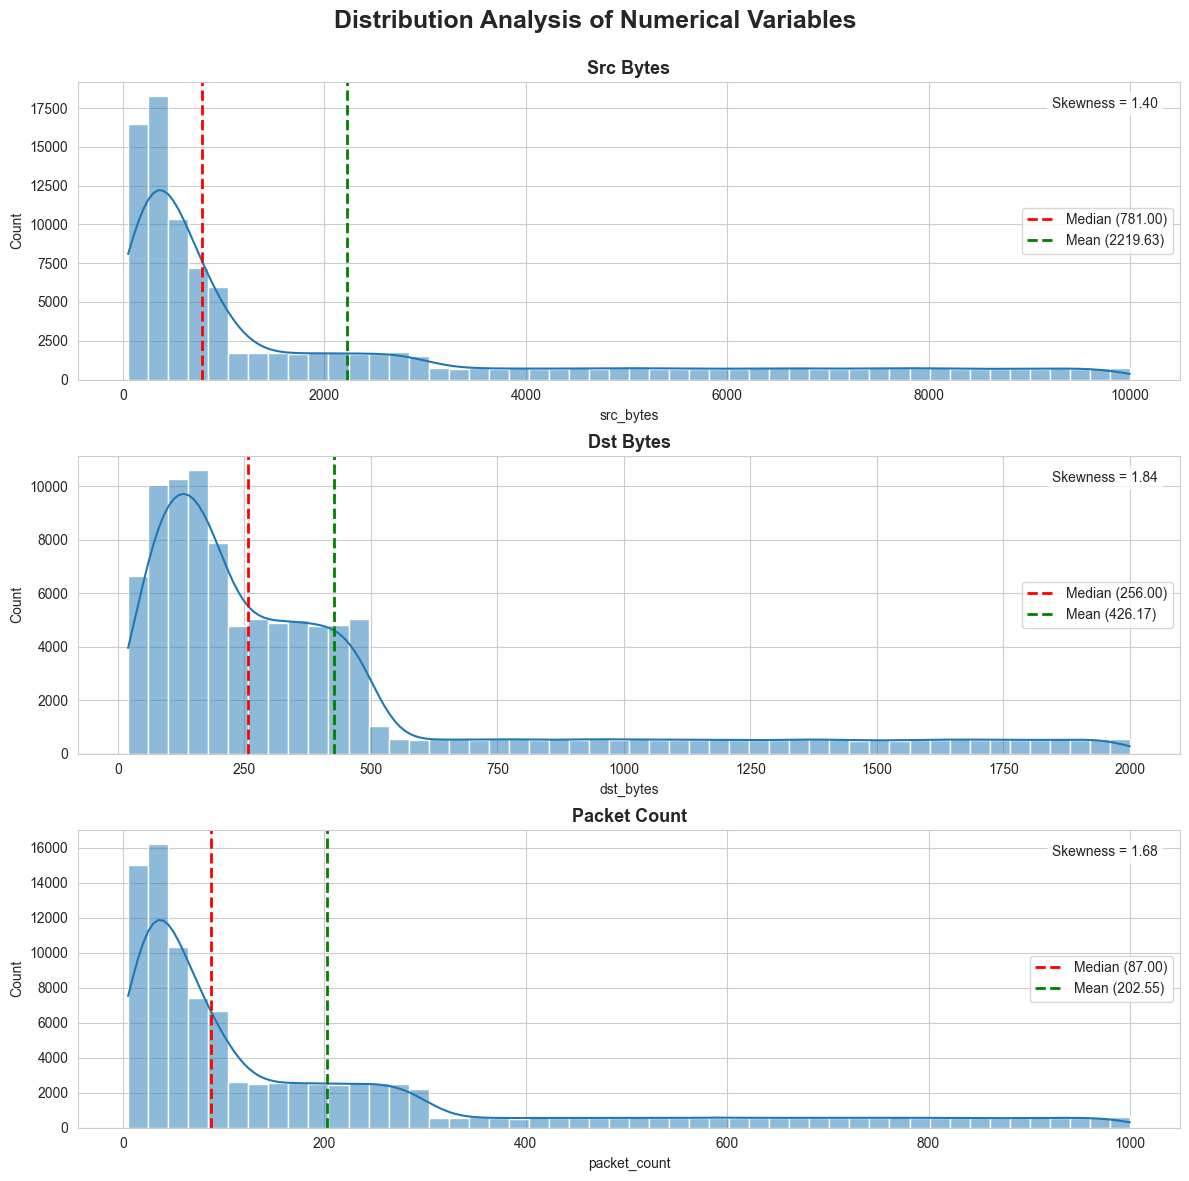

In [27]:
from scipy.stats import skew
import os

target_columns = [
    'src_bytes',
    'dst_bytes',
    'packet_count'
]

fig, axes = plt.subplots(
    nrows=3,
    ncols=1,
    figsize=(12, 12)
)

axes = axes.flatten()

for ax, col in zip(axes, target_columns):

    mean_val = df[col].mean()
    median_val = df[col].median()
    skew_val = skew(df[col])

    sns.histplot(
        data=df,
        x=col,
        bins=50,
        kde=True,
        ax=ax
    )

    ax.axvline(
        median_val,
        color='red',
        linestyle='--',
        linewidth=2,
        label=f'Median ({median_val:.2f})'
    )

    ax.axvline(
        mean_val,
        color='green',
        linestyle='--',
        linewidth=2,
        label=f'Mean ({mean_val:.2f})'
    )

    ax.set_title(
        f'{col.replace("_", " ").title()}',
        fontsize=13,
        fontweight='bold'
    )

    ax.set_xlabel(col)
    ax.set_ylabel('Count')

    ax.text(
        0.98,
        0.95,
        f'Skewness = {skew_val:.2f}',
        transform=ax.transAxes,
        ha='right',
        va='top',
        fontsize=10,
        bbox=dict(
            boxstyle='round',
            facecolor='white',
            alpha=0.8
        )
    )

    ax.legend()

plt.tight_layout()

fig.suptitle(
    'Distribution Analysis of Numerical Variables',
    fontsize=18,
    fontweight='bold'
)

fig.subplots_adjust(top=0.92)

os.makedirs('img', exist_ok=True)

filepath = os.path.join(
    'img',
    'Distribution Analysis of Numerical Variables.png'
)

plt.savefig(
    filepath,
    dpi=300,
    bbox_inches='tight',
    facecolor='white'
)

plt.show()

### Insight

- numeric variables (`src_bytes`, `dst_bytes`, and `packet_count`) show a similar distribution pattern, namely **positively skewed (right-skewed)** with a mean value that is consistently higher than the median.
- This indicates that most of the connections in the dataset have relatively low to moderate network activity, while there are a small number of connections with very high values ​​that form the long tail of the distribution.
- A skewness value in the range of 1.40–1.84 indicates that the data distribution is asymmetric and tends to be dominated by small-value observations. A significant difference between the mean and median indicates a connection with a significantly higher data transfer volume or number of packets than the majority of other connections.
- This pattern indicates that the network traffic characteristics in the dataset are heterogeneous and likely comprise several distinct behavioral clusters. Therefore, further analysis based on `attack_type` is needed to identify whether these high-activity connections are related to a specific type of attack or are part of normal traffic.

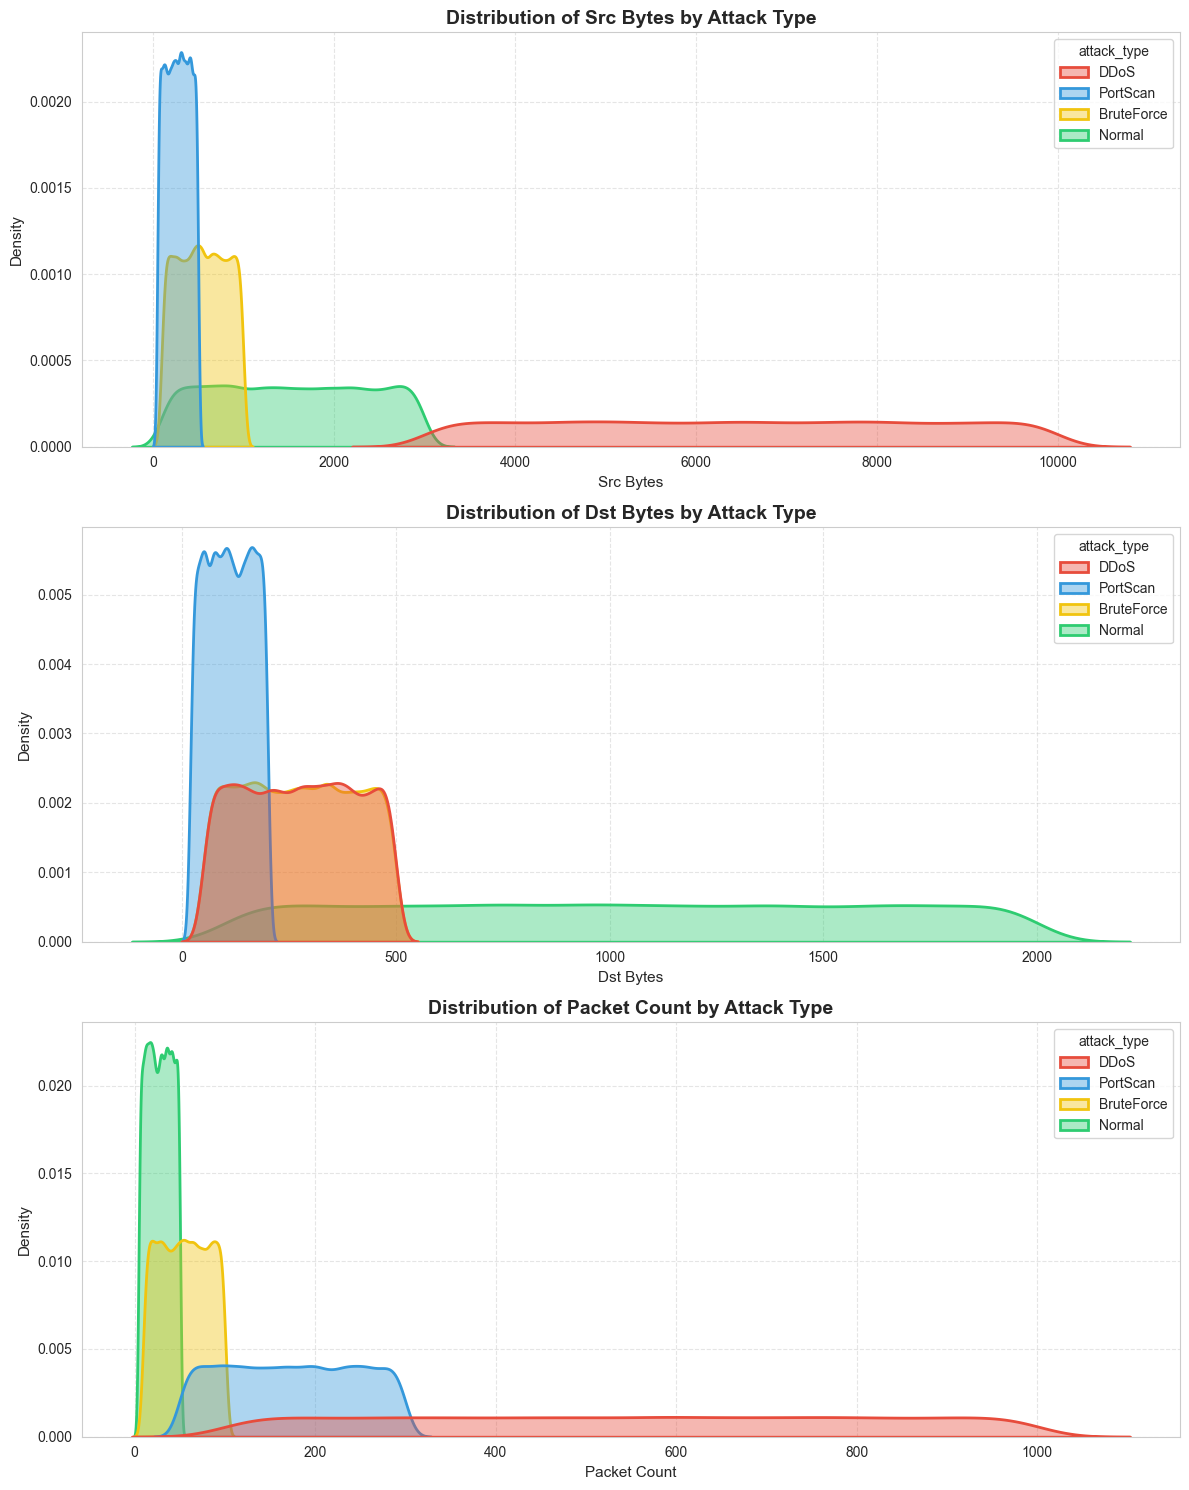

In [28]:
target_columns = [
    'src_bytes',
    'dst_bytes',
    'packet_count'
]

fig, axes = plt.subplots(
    nrows=3,
    ncols=1,
    figsize=(12, 15)
)

axes = axes.flatten()

palette = {'Normal': '#2ecc71', 'DDoS': '#e74c3c', 'PortScan': '#3498db', 'BruteForce': '#f1c40f'}

for ax, col in zip(axes, target_columns):
    
    sns.kdeplot(
        data=df,
        x=col,
        hue='attack_type',
        fill=True,
        common_norm=False,
        palette=palette,
        alpha=0.4,
        linewidth=2,
        ax=ax
    )

    ax.set_title(
        f'Distribution of {col.replace("_", " ").title()} by Attack Type',
        fontsize=14,
        fontweight='bold'
    )
    ax.set_xlabel(col.replace("_", " ").title(), fontsize=11)
    ax.set_ylabel('Density', fontsize=11)
    ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()

os.makedirs('img', exist_ok=True)
filepath = os.path.join(
    'img',
    'Distribution_Analysis_by_Attack_Type.png'
)

plt.savefig(
    filepath,
    dpi=300,
    bbox_inches='tight',
    facecolor='white'
)

plt.show()


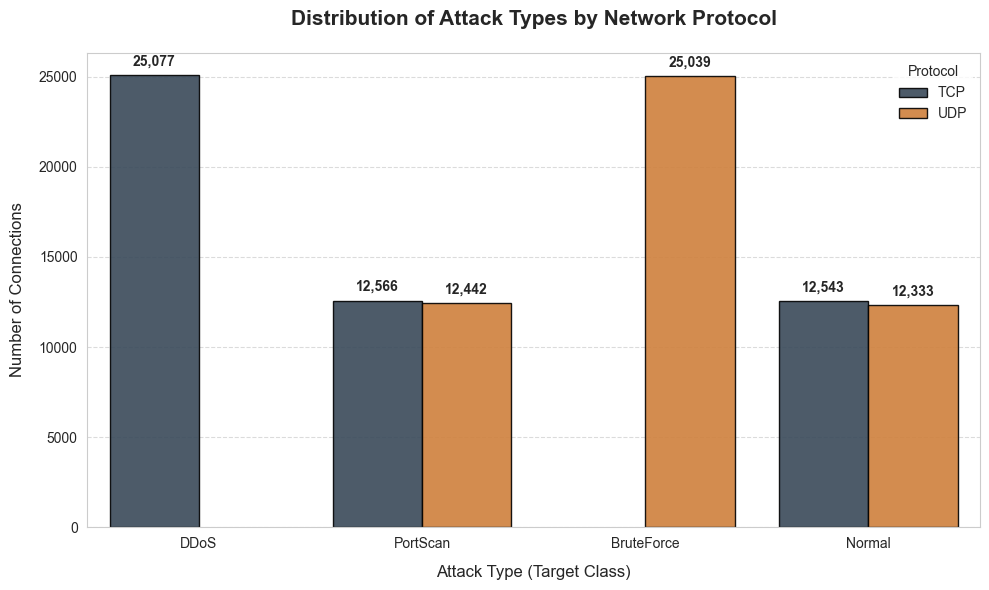

In [29]:
plt.figure(figsize=(10, 6))

palette = {'TCP': '#34495e', 'UDP': '#e77e23'}

ax = sns.countplot(
    data=df,
    x='attack_type',
    hue='protocol',
    palette=palette,
    edgecolor='black',
    alpha=0.9
)

for p in ax.patches:
    height = p.get_height()
    if height > 0: 
        ax.annotate(
            f'{height:,.0f}',
            (p.get_x() + p.get_width() / 2., height),
            ha='center',
            va='bottom',
            fontsize=10,
            fontweight='bold',
            xytext=(0, 5),
            textcoords='offset points'
        )

ax.set_title(
    'Distribution of Attack Types by Network Protocol', 
    fontsize=15, 
    fontweight='bold', 
    pad=20
)
ax.set_xlabel('Attack Type (Target Class)', fontsize=12, labelpad=10)
ax.set_ylabel('Number of Connections', fontsize=12, labelpad=10)
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.legend(title='Protocol', frameon=True, facecolor='white', edgecolor='none')
plt.tight_layout()

filepath = os.path.join(
    'img',
    'attack_type_protocol_distribution.png'
)

plt.savefig(
    filepath,
    dpi=300,
    bbox_inches='tight',
    facecolor='white'
)

plt.show()


## Chapter 3 : EDA

### 3.1 Are there distinct patterns that separate the different attack types based on the combination of network traffic features?

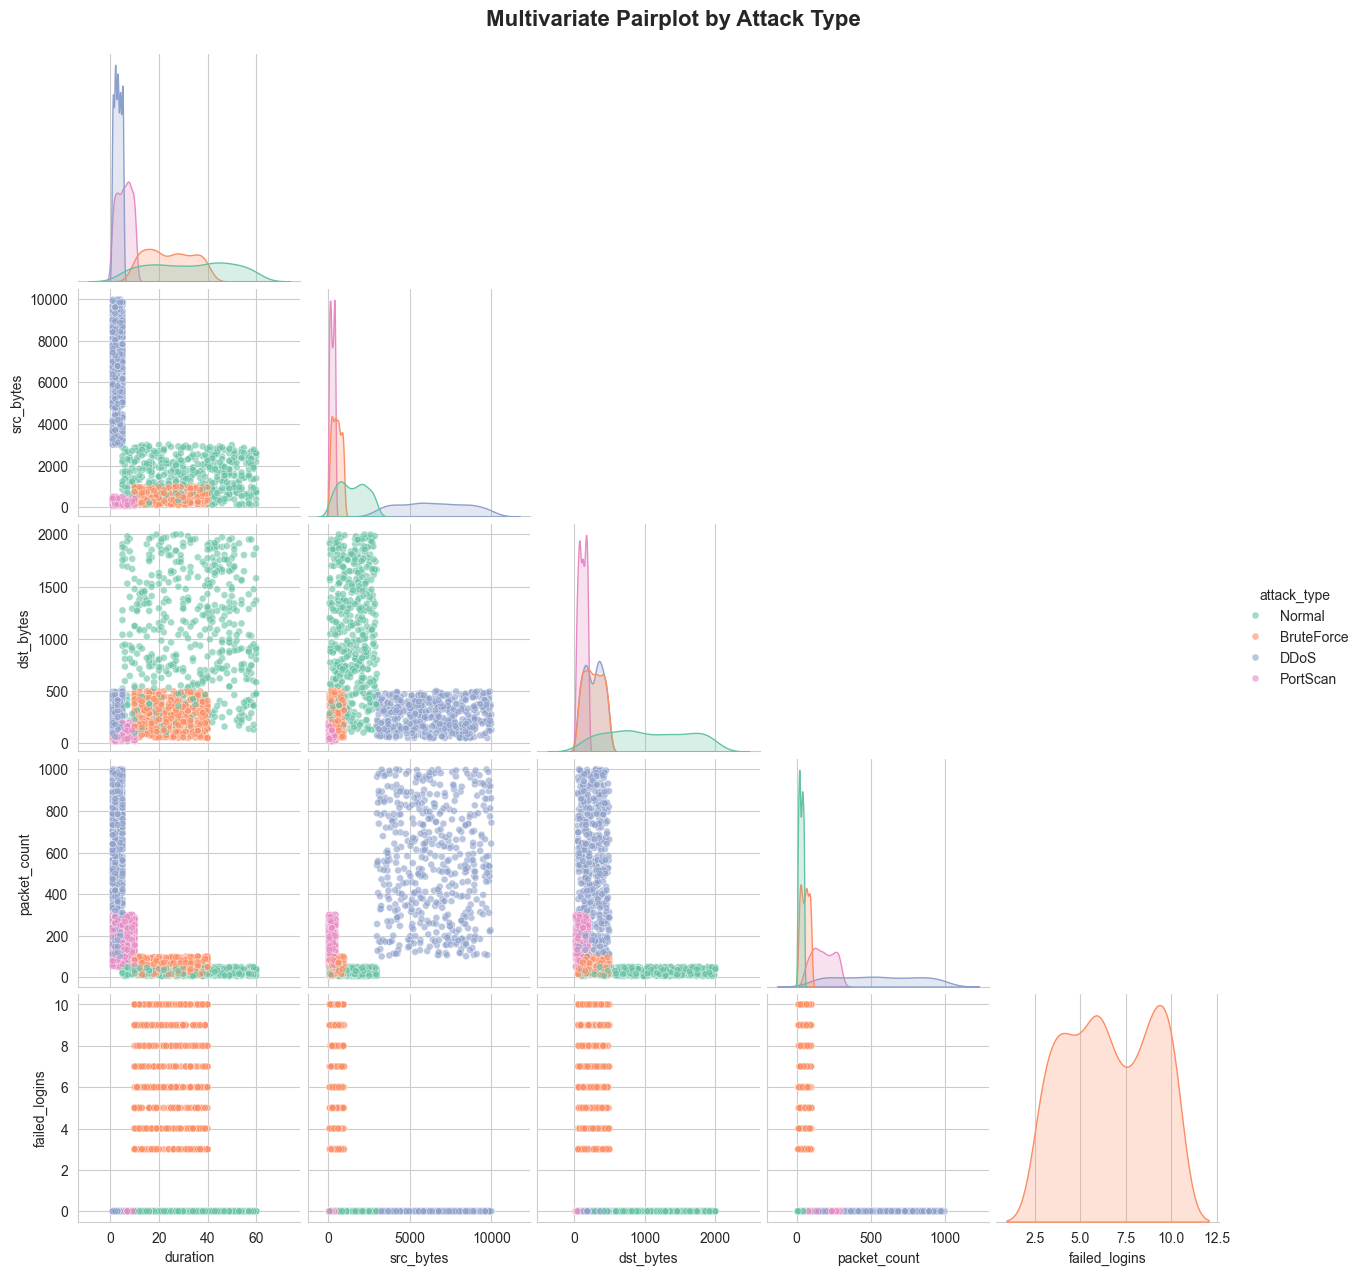

In [30]:
df_sample = df.sample(2000, random_state=42)

cols_to_plot = ['duration', 'src_bytes', 'dst_bytes', 'packet_count', 'failed_logins', 'attack_type']

sns.pairplot(
    data=df_sample[cols_to_plot],
    hue='attack_type',
    palette='Set2',
    diag_kind='kde',
    corner=True,
    plot_kws={'alpha': 0.6, 's': 25}
)

filepath = os.path.join('img', 'Multivariate Pairplot by Attack Type.png')
plt.savefig(filepath, dpi=300, bbox_inches='tight')

plt.suptitle('Multivariate Pairplot by Attack Type', y=1.02, fontsize=16, fontweight='bold')
plt.show()

### Insights:

1. **BruteForce Attack Profile (Failed Logins as a Key Discriminator):**
   * **BruteForce** (orange) is the **only** class that exhibits `failed_logins` greater than zero (ranging from 1 to 10). 
   * For all other classes (**Normal**, **DDoS**, and **PortScan**), the failed login count is strictly zero. This makes `failed_logins` a perfect single-feature predictor for BruteForce attacks.

2. **DDoS Attack Profile (High Volume, Low Latency):**
   * **DDoS** (blue) is clearly clustered in the upper-right of the `src_bytes` vs `packet_count` scatter plot. It is characterized by high `src_bytes` (3,000 to 10,000 bytes) and high `packet_count` (200 to 1,000 packets).
   * Despite the massive data volume, DDoS traffic has a very short `duration` (mostly < 5 seconds), forming a tall vertical stripe on the left side of the `duration` vs `src_bytes` plot.

3. **PortScan Attack Profile (Low Volume Probe):**
   * **PortScan** (pink) is heavily clustered in the bottom-left corner of almost all bivariate plots. It shows very low `duration`, low `packet_count` (< 200), and near-zero `src_bytes` and `dst_bytes`. 
   * This represents the typical behavior of scanning ports quickly with minimal data payload.

4. **Normal Traffic Profile (Balanced and Long Connections):**
   * **Normal** traffic (green) is widely spread across the `duration` range (up to 60 seconds) and shows a balanced distribution of `dst_bytes` (up to 2,000 bytes).
   * It is easily distinguished from DDoS by its lower packet count and longer duration, and from BruteForce by having zero failed logins.

### 3.2 How do TCP and UDP protocols compare in terms of security, and which protocol is more susceptible to spesific attack type?

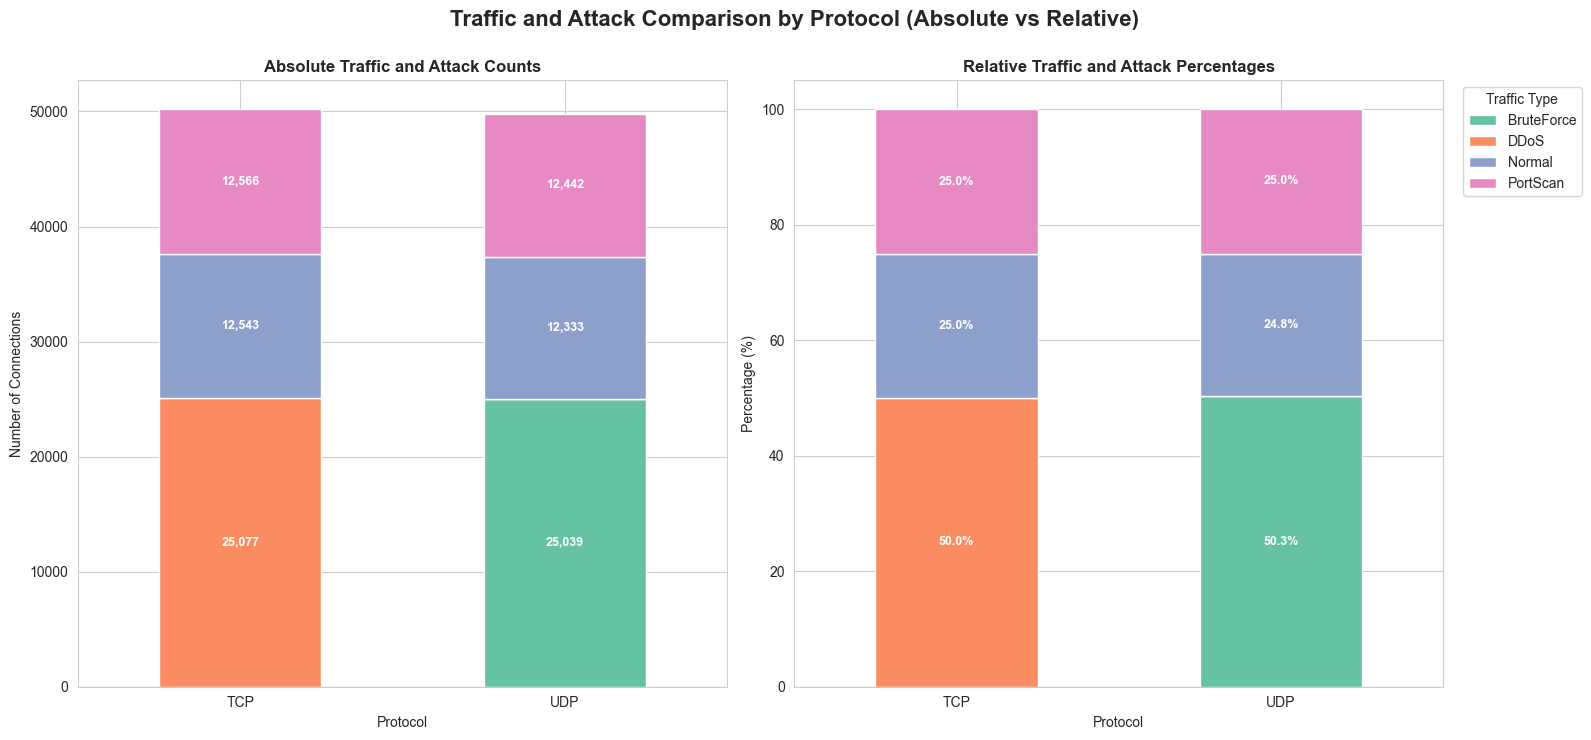

In [33]:
# Calculate absolute counts and percentages
protocol_counts = pd.crosstab(df['protocol'], df['attack_type'])
protocol_pct = pd.crosstab(df['protocol'], df['attack_type'], normalize='index') * 100

colors = sns.color_palette('Set2', len(df['attack_type'].unique()))

# Create side-by-side subplots (1 row, 2 columns)
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 7))

# 1. Left Plot: Absolute Counts
protocol_counts.plot(kind='bar', stacked=True, color=colors, ax=axes[0])
axes[0].set_title('Absolute Traffic and Attack Counts', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Protocol', fontsize=10)
axes[0].set_ylabel('Number of Connections', fontsize=10)
axes[0].set_xticklabels(protocol_counts.index, rotation=0)
axes[0].get_legend().remove()  # Remove individual legend to avoid clutter

for p in axes[0].patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy() 
    if height > 0:
        axes[0].annotate(f'{int(height):,}', (x + width/2, y + height/2), 
                         ha='center', va='center', color='white', fontweight='bold', fontsize=9)

# 2. Right Plot: Relative Percentages
protocol_pct.plot(kind='bar', stacked=True, color=colors, ax=axes[1])
axes[1].set_title('Relative Traffic and Attack Percentages', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Protocol', fontsize=10)
axes[1].set_ylabel('Percentage (%)', fontsize=10)
axes[1].set_xticklabels(protocol_pct.index, rotation=0)
axes[1].legend(title='Traffic Type', bbox_to_anchor=(1.02, 1), loc='upper left')

for p in axes[1].patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy() 
    if height > 0:
        axes[1].annotate(f'{height:.1f}%', (x + width/2, y + height/2), 
                         ha='center', va='center', color='white', fontweight='bold', fontsize=9)

plt.tight_layout()

filepath = os.path.join('img', 'Traffic and Attack Comparison by Protocol.png')
plt.savefig(filepath, dpi=300, bbox_inches='tight')

plt.suptitle('Traffic and Attack Comparison by Protocol (Absolute vs Relative)', y=1.05, fontsize=16, fontweight='bold')
plt.show()


### Insights:

1. **Equal Traffic Scale and Threat Exposure:**
   * In terms of total traffic volume, **TCP** (50,186 connections) and **UDP** (49,814 connections) are almost identical.
   * Both protocols face an equal volume of threat: **TCP** was attacked **37,643 times** (75.0%), and **UDP** was attacked **37,481 times** (75.2%). 

2. **Protocol-Specific Attack Target Segmentation:**
   * **DDoS** (orange) is exclusively targeted at the **TCP** protocol, making up exactly **50.0%** (25,077 connections) of all TCP traffic.
   * **BruteForce** (green) is exclusively targeted at the **UDP** protocol, making up **50.3%** (25,039 connections) of all UDP traffic.

3. **Uniform Scanning and Normal Baseline:**
   * **PortScan** (pink) behaves almost identically across both protocols, representing exactly **25.0%** of the traffic for both TCP (12,566 connections) and UDP (12,442 connections).
   * **Normal** traffic (blue) remains stable at approximately **25%** for both protocols (25.0% for TCP vs. 24.8% for UDP).

### Conclusion:
Neither protocol is safer, as both have a high attack rate of ~75%. However, security defenses should be tailored to the protocol:
* **TCP security** must prioritize mitigating **DDoS** floods.
* **UDP security** must focus on rate-limiting and access control to prevent **BruteForce** login attempts.


### 3.3 What is the strength of the correlation between the numerical network metrics?

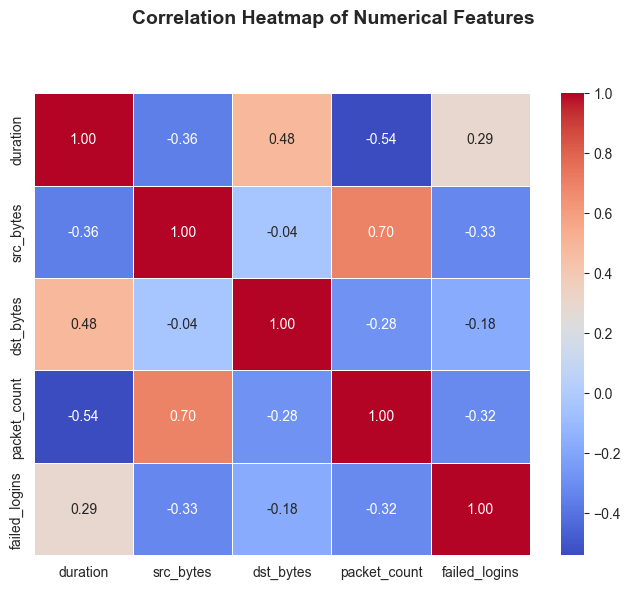

In [34]:
corr_matrix = df[['duration', 'src_bytes', 'dst_bytes', 'packet_count', 'failed_logins']].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, ax=ax)

filepath = os.path.join('img', 'Correlation Heatmap of Numerical Features.png')
plt.savefig(filepath, dpi=300, bbox_inches='tight')

plt.suptitle('Correlation Heatmap of Numerical Features', y=1.02, fontsize=14, fontweight='bold')
plt.show()


### 3.5 Which attack types consume the highest bandwidth (throughput in bytes per second)?

C:\Users\FATHIR\AppData\Local\Temp\ipykernel_13876\3934211184.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='attack_type', y='troughput', palette='Set2', errorbar=None, ax=ax)


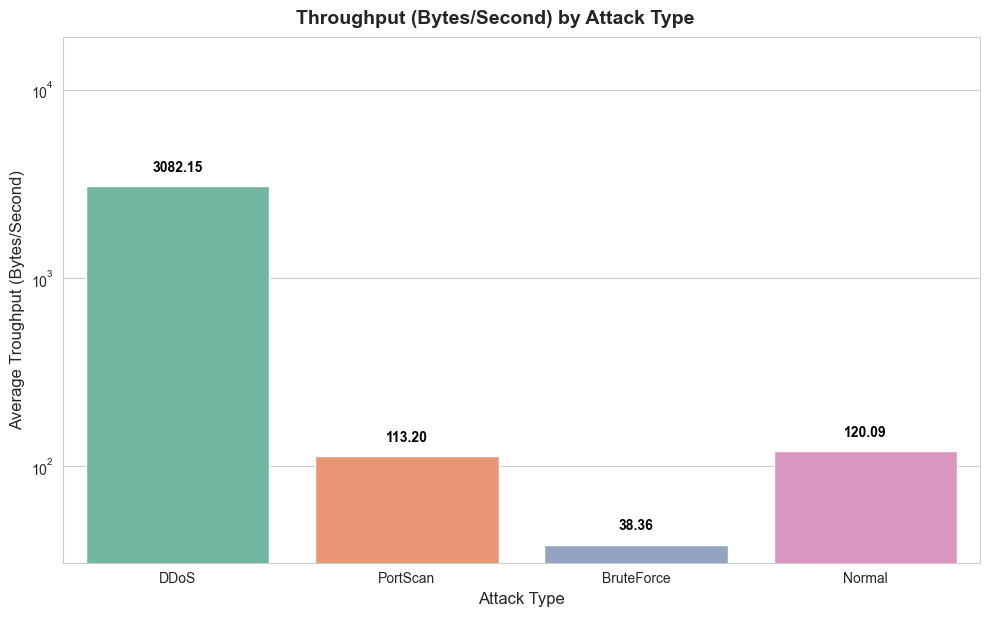

In [37]:
df['troughput'] = ((df['src_bytes'] + df['dst_bytes']) / df['duration'])

fig, ax = plt.subplots(figsize=(10,6))
sns.barplot(data=df, x='attack_type', y='troughput', palette='Set2', errorbar=None, ax=ax)

ax.set_yscale('log')
ax.set_ylim(top=ax.get_ylim()[1] * 5)

plt.xlabel('Attack Type', fontsize=12)
plt.ylabel('Average Troughput (Bytes/Second)', fontsize=12)

for p in ax.patches :
    width, height = p.get_width(), p.get_height()
    x,y = p.get_xy()
    if height > 0 :
        ax.annotate(f"{height:.2f}", (x + width/2, height * 1.15),
                    ha='center', va='bottom', color='black', fontweight='bold', fontsize=10)
plt.tight_layout()

filepath = os.path.join('img', 'Throughput by Attack Type.png')
plt.savefig(filepath, dpi=300, bbox_inches='tight')
plt.suptitle('Throughput (Bytes/Second) by Attack Type', y=1.02, fontsize=14, fontweight='bold')
plt.show()


### Insights:

* **DDoS (Extreme Bandwidth Flood):** Average throughput is exceptionally high at **3,082.15 Bytes/s** (~25x higher than Normal traffic). This confirms its objective to overwhelm the network by flooding it with high-volume data.
* **BruteForce (Low-and-Slow Activity):** It consumes the lowest bandwidth at **38.36 Bytes/s**. Since BruteForce consists of periodic login attempts, it keeps throughput minimal to bypass volume-based alarms.
* **PortScan (Normal-Like Throughput):** PortScan averages **113.20 Bytes/s**, which is almost identical to Normal traffic (**120.09 Bytes/s**). This enables the scanning activity to blend in with normal baseline traffic.

### Security Takeaway:
While throughput anomaly detection is highly effective for flagging **DDoS**, other rules (such as tracking failed login counts) are needed to identify **BruteForce** and **PortScan** attacks.

### 3.6 How does the average packet payload size (bytes per packet) differ between benign traffic and various cyber attacks?

C:\Users\FATHIR\AppData\Local\Temp\ipykernel_13876\707192225.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='attack_type', y='bytes_per_packet', palette='Set2', errorbar=None, ax=ax)


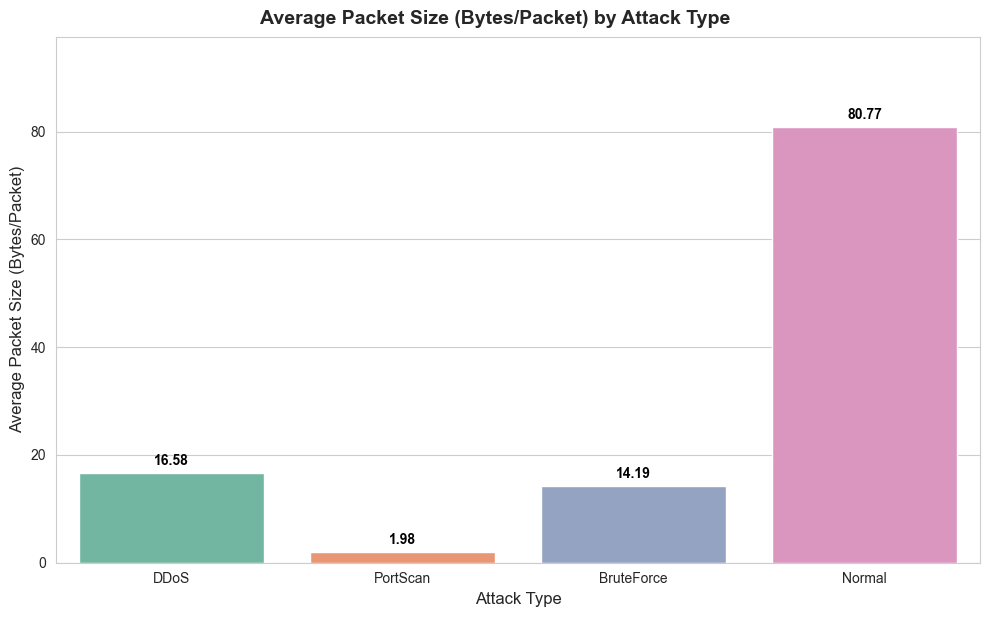

In [38]:
df['bytes_per_packet'] = df['src_bytes'] / df['packet_count']

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=df, x='attack_type', y='bytes_per_packet', palette='Set2', errorbar=None, ax=ax)
ax.set_ylim(top=ax.get_ylim()[1] * 1.15)

plt.xlabel('Attack Type', fontsize=12)
plt.ylabel('Average Packet Size (Bytes/Packet)', fontsize=12)

for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy()
    if height > 0:
        ax.annotate(f"{height:.2f}", (x + width/2, height + 1),
                    ha='center', va='bottom', color='black', fontweight='bold', fontsize=10)

plt.tight_layout()

filepath = os.path.join('img', 'Average Packet Size by Attack Type.png')
plt.savefig(filepath, dpi=300, bbox_inches='tight')
plt.suptitle('Average Packet Size (Bytes/Packet) by Attack Type', y=1.02, fontsize=14, fontweight='bold')
plt.show()


### Insights:

* **Normal Traffic (Heavy Payload):** Averages **80.77 Bytes/Packet**, which is significantly larger than any attack traffic. This indicates that normal traffic carries real application-level payloads (e.g., file transfers or web pages).
* **Automated Attacks (Small Payload):** **DDoS (16.58 Bytes)** and **BruteForce (14.19 Bytes)** consist of relatively small packets, which is typical of automated scripts sending high frequencies of minimal request payloads.
* **PortScan (Micro Packets):** Averages a tiny **1.98 Bytes/Packet**, confirming that PortScan is composed of simple handshake connection probes (e.g., SYN packets) without any data payload.


### 3.7 Is there a significant data transmission imbalance (asymmetry) between source and destination bytes during network attacks?

C:\Users\FATHIR\AppData\Local\Temp\ipykernel_13876\2036197424.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='attack_type', y='asymmetry_ratio', palette='Set2', errorbar=None, ax=ax)


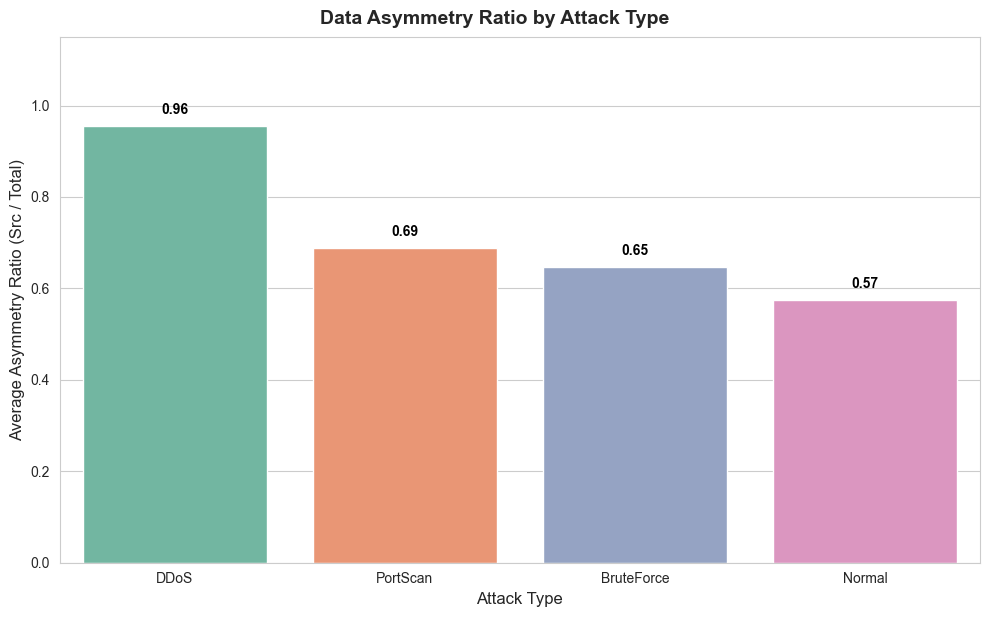

In [39]:
df['asymmetry_ratio'] = df['src_bytes'] / (df['src_bytes'] + df['dst_bytes'])

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=df, x='attack_type', y='asymmetry_ratio', palette='Set2', errorbar=None, ax=ax)
ax.set_ylim(top=1.15)

plt.xlabel('Attack Type', fontsize=12)
plt.ylabel('Average Asymmetry Ratio (Src / Total)', fontsize=12)

for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy()
    if height > 0:
        ax.annotate(f"{height:.2f}", (x + width/2, height + 0.02),
                    ha='center', va='bottom', color='black', fontweight='bold', fontsize=10)

plt.tight_layout()

filepath = os.path.join('img', 'Data Asymmetry Ratio by Attack Type.png')
plt.savefig(filepath, dpi=300, bbox_inches='tight')
plt.suptitle('Data Asymmetry Ratio by Attack Type', y=1.02, fontsize=14, fontweight='bold')
plt.show()


### Insights:

* **DDoS (Severe Asymmetry):** Averages an extreme ratio of **0.96**, meaning 96% of all data transmitted flows one-way from the source. This is a classic flooding pattern where the attacker sends massive data without expecting or receiving responses.
* **Normal Traffic (Interactive & Balanced):** Averages **0.57**, which is closest to a balanced 50/50 transmission. This reflects normal web browsing or interactive sessions where requests are met with responses of comparable size.
* **PortScan & BruteForce (Moderate Asymmetry):** Show ratios of **0.69** and **0.65** respectively, reflecting that they send slightly more query data than they receive.
